# Section 3: Logistic Growth Model

## Background
The **logistic growth model represents how populations change over time when resources are limited**. The logistic model incorporates a carrying capacity—the maximum population size a specific environment can sustainably support.

**Key Concepts**
* **Carrying Capacity ($K$)**: A ceiling that limits population growth due to limited resources (food, space, water, etc.).
* **Intrinsic Growth Rate ($r$)**: The rate at which a population would grow if there were unlimited resources.
* **S-Shaped Curve**: The logistic growth model plots as an S-shaped curve. Growth is initially exponential, then slows as it approaches the carrying capacity.



## Equation of Logistic Growth

**Differential equation of logistic growth:**
$$ \frac{dP}{dt} = rP\left(1 - \frac{P}{K}\right) $$

**Iterative Form:**
$$ P(t_{i+1}) = P(t_i) + rP(t_i)\left(1 - \frac{P(t_i)}{K}\right) \Delta t $$

**Explicit solution:**
$$ P(t) = \frac{K}{1 + \left(\frac{K - P_0}{P_0} \right) e^{-rt}} $$

Where:
* $P(t_i)$ is the population at time $t_i$
* $P_0$ is the initial population
* $r$ is the growth rate
* $K$ is the carrying capacity
* $t$ is time, $\Delta t$ is the time step 

## Discussion: Railway Construction

Consider historical data showing French vs. English railway construction. 

**Topics for discussion**
* Why do you think that the French railway construction follows logistic growth but the English does not? 
* How would you explain **carrying capacity** in the context of railroad construction? 
* What may affect the carrying capacity for railways? Is the capacity constant or dynamic? 

## Closer Look at the Equation & Equilibrium

Let’s explore the equation: try to figure out how the carrying capacity affects population growth. Try different combinations of $P$ and $K$. What are the equilibrium solutions where there is no population growth? 

To find equilibrium solutions, we set the derivative to zero:
$$ 0 = rP \left(1 - \frac{P}{K}\right) $$

This equation is satisfied when either:
1. The population is zero: $P = 0$
2. The growth rate is zero: $r = 0$
3. The population size equals the carrying capacity: $P = K$

## History


* **Pierre Verhulst**: A Belgian mathematician who first proposed the logistic model in the 1830s and 1840s. His model sought to refine the exponential population growth model of Malthus.
* Verhulst got inspiration from the concept of intraspecific competition—the idea that as populations get larger, individuals compete more intensely for limited resources.
* This equation was published after Verhulst had read Thomas Malthus' *An Essay on the Principle of Population*.

## Applications
The logistic growth model has extensive applications:
* **Biology**: Used extensively in modeling animal, plant, and bacterial population growth.
* **Epidemiology and medicine**: Helps analyze how diseases spread within a population or tumor growth.
* **Economics**: Modeling market adoption of new products or technologies—a diffusion of innovation.
* **Linguistics**: An innovation that is at first marginal begins to spread more quickly with time, and then more slowly as it becomes more universally adopted.
* **Statistics and machine learning**: Logistic functions are often used in artificial neural networks to introduce nonlinearity in the model—but it is mostly for the shape.

## Exercises

**Task 1 & 2 Overview**
1. Numerically solve the logistic growth equation and plot: Population size vs. time, Population increase vs. time, Per capita growth rate vs. population size, Population increase vs. population size.
2. Adjust the appearance of the plot: 
    * Add a plot title and axis labels 
    * Change line thickness and appearance 
    * Experiment with other changes 
3. Experiment with model parameters:
    * Try to increase the initial population over the capacity of the environment 

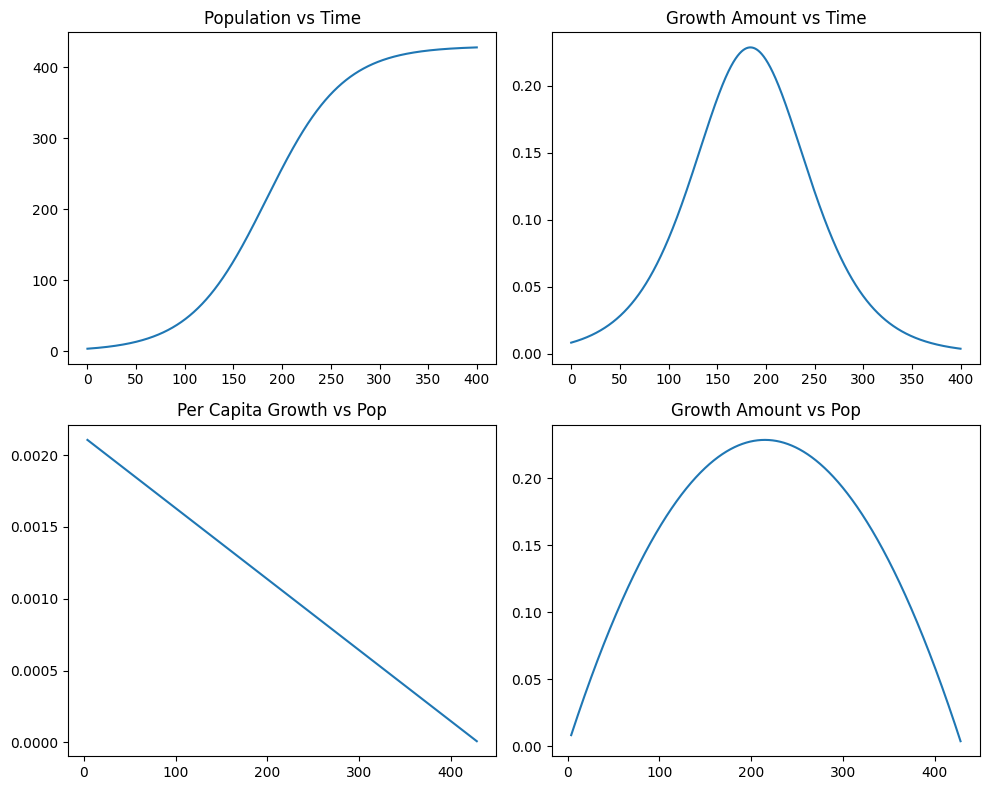

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters and Time
P0, r, K = 3.9, 0.0255, 430
t = np.arange(0, 400, 1/12)

# Vectorized Logistic Growth (Analytical Solution)
# P(t) = K / (1 + ((K - P0) / P0) * exp(-rt))
P = K / (1 + ((K - P0) / P0) * np.exp(-r * t))
P_diff = r * P * (1 - P / K) * (1/12)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
plots = [
    (t, P, "Population vs Time"),
    (t, P_diff, "Growth Amount vs Time"),
    (P, P_diff / P, "Per Capita Growth vs Pop"),
    (P, P_diff, "Growth Amount vs Pop")
]

for ax, (x, y, title) in zip(axs.flat, plots):
    ax.plot(x, y)
    ax.set_title(title)

plt.tight_layout()
plt.show()

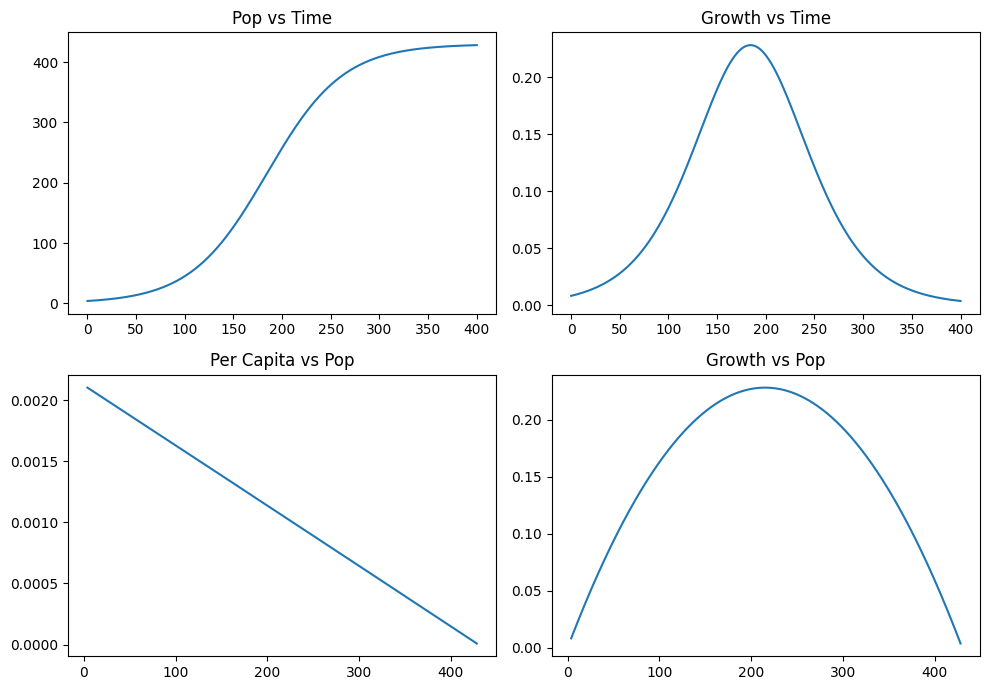

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Params & Time
P0, r, K, dt = 3.9, 0.0255, 430, 1/12
t = np.arange(0, 400 + dt, dt)
P = np.zeros(len(t))
P[0] = P0

# Iterative solution
for i in range(len(t) - 1):
    P[i+1] = P[i] + r * P[i] * (1 - P[i] / K) * dt

# Derived Data
P_diff = np.concatenate([[np.nan], np.diff(P)])
plots = [(t, P, "Pop vs Time"), (t, P_diff, "Growth vs Time"),  (P, P_diff/P, "Per Capita vs Pop"), (P, P_diff, "Growth vs Pop")]

fig, axs = plt.subplots(2, 2, figsize=(10, 7))
for ax, (x, y, title) in zip(axs.flat, plots):
    ax.plot(x, y)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Task 3: USA Population Modeling

4. Model the population of the USA and compare it with real data.

*For the population model of the USA, set the step size to 1 month, the initial population size to 5.2 million in 1790, the growth rate to 0.0237, and the capacity of the environment to 460 million.*

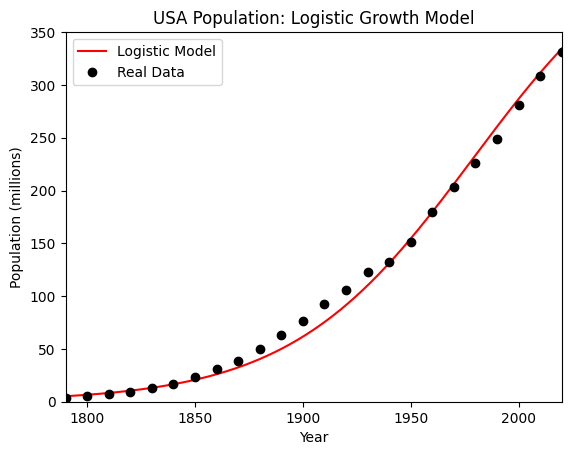

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r, P0, K, start_year = 0.0237, 5.2, 460, 1790
t_usa = np.arange(0, 240, 10)
P_usa = np.array([3.9, 5.3, 7.2, 9.6, 12.9, 17.1, 23.2, 31.4, 38.6, 50.2, 63.0, 76.2, 92.2, 106.0, 123.2, 132.2, 151.3, 179.3, 203.3, 226.5, 248.7, 281.4, 308.7, 331.4])

dt = 1/12
t_num = np.arange(0, 230 + dt, dt)
P_num = np.zeros(len(t_num))
P_num[0] = P0

for i in range(len(t_num) - 1):
    P_num[i+1] = P_num[i] + r * P_num[i] * (1 - P_num[i] / K) * dt

# Plotting
plt.plot(t_num + start_year, P_num, 'r-', label='Logistic Model')
plt.plot(t_usa + start_year, P_usa, 'ko', label='Real Data')
plt.axis([1790, 2020, 0, 350])
plt.legend(); plt.title("USA Population: Logistic Growth Model")
plt.xlabel("Year"); plt.ylabel("Population (millions)")
plt.show()